In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import os
path = '../data'  # Path to the IAM dataset

# List what's in the dataset
print("Dataset contents:")
for item in os.listdir(path):
    print(f"- {item}")

# Show first image found
for root, dirs, files in os.walk(f'{path}/data'):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, file)
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(file)
            plt.axis('off')
            plt.show()
            break
    break

Dataset contents:
- 613
- 645
- 380
- 352
- 134
- 561
- 140
- 301
- 539
- 649
- 042
- 265
- 568
- 573
- 164
- 450
- 389
- 624
- 275
- 239
- 336
- 024
- 151
- 165
- 162
- 479
- 257
- 260
- 615
- 141
- 011
- 496
- 405
- 040
- 601
- 634
- 655
- 452
- 341
- 053
- 362
- 661
- 238
- 524
- 670
- 659
- 153
- 365
- 106
- 009
- 112
- 147
- 536
- 642
- 170
- 545
- 221
- 193
- 461
- 463
- 616
- 591
- 618
- 572
- 256
- 111
- 482
- 113
- 138
- 107
- 518
- 054
- 242
- 519
- 004
- 030
- 335
- 150
- 641
- 296
- 249
- 118
- 386
- 447
- 401
- 628
- 458
- 309
- 160
- 049
- 086
- 508
- 418
- 167
- 219
- 347
- 105
- 264
- 433
- 201
- 434
- 472
- 115
- 495
- 392
- 487
- 521
- 324
- 449
- 253
- 553
- 443
- 363
- 513
- 559
- 383
- 104
- 299
- 310
- 132
- 308
- 502
- 469
- 638
- 286
- 529
- 130
- 351
- 258
- 488
- 227
- 176
- 406
- 400
- 359
- 586
- 408
- 419
- 582
- 666
- 492
- 282
- 385
- 547
- 607
- 252
- 183
- 287
- 667
- 523
- 022
- 580
- 668
- 372
- 639
- 367
- 059
- 320
- 442
- 060
- 557
- 583
- 377
- 34

In [2]:
# Load model directly
from transformers import AutoModel, AutoTokenizer
import torch

model_name = 'deepseek-ai/DeepSeek-OCR'
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

model = AutoModel.from_pretrained("deepseek-ai/DeepSeek-OCR", trust_remote_code=True, torch_dtype="auto")
model = model.eval().cuda().to(torch.bfloat16)


/home/diego/Documents/clases/procesamiento lenguaje natural/proyecto/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at deepseek-ai/DeepSeek-OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DeepseekOCRForCausalLM were not initialized f

In [3]:
from datasets import Dataset, Image
import glob

image_paths = glob.glob(os.path.join(path, "**", "*.png"), recursive=True)
dataset = Dataset.from_dict({"image": image_paths}).cast_column("image", Image())
img_key = 'image'

In [4]:
index = 4
dataset[index]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=2479x3542>}

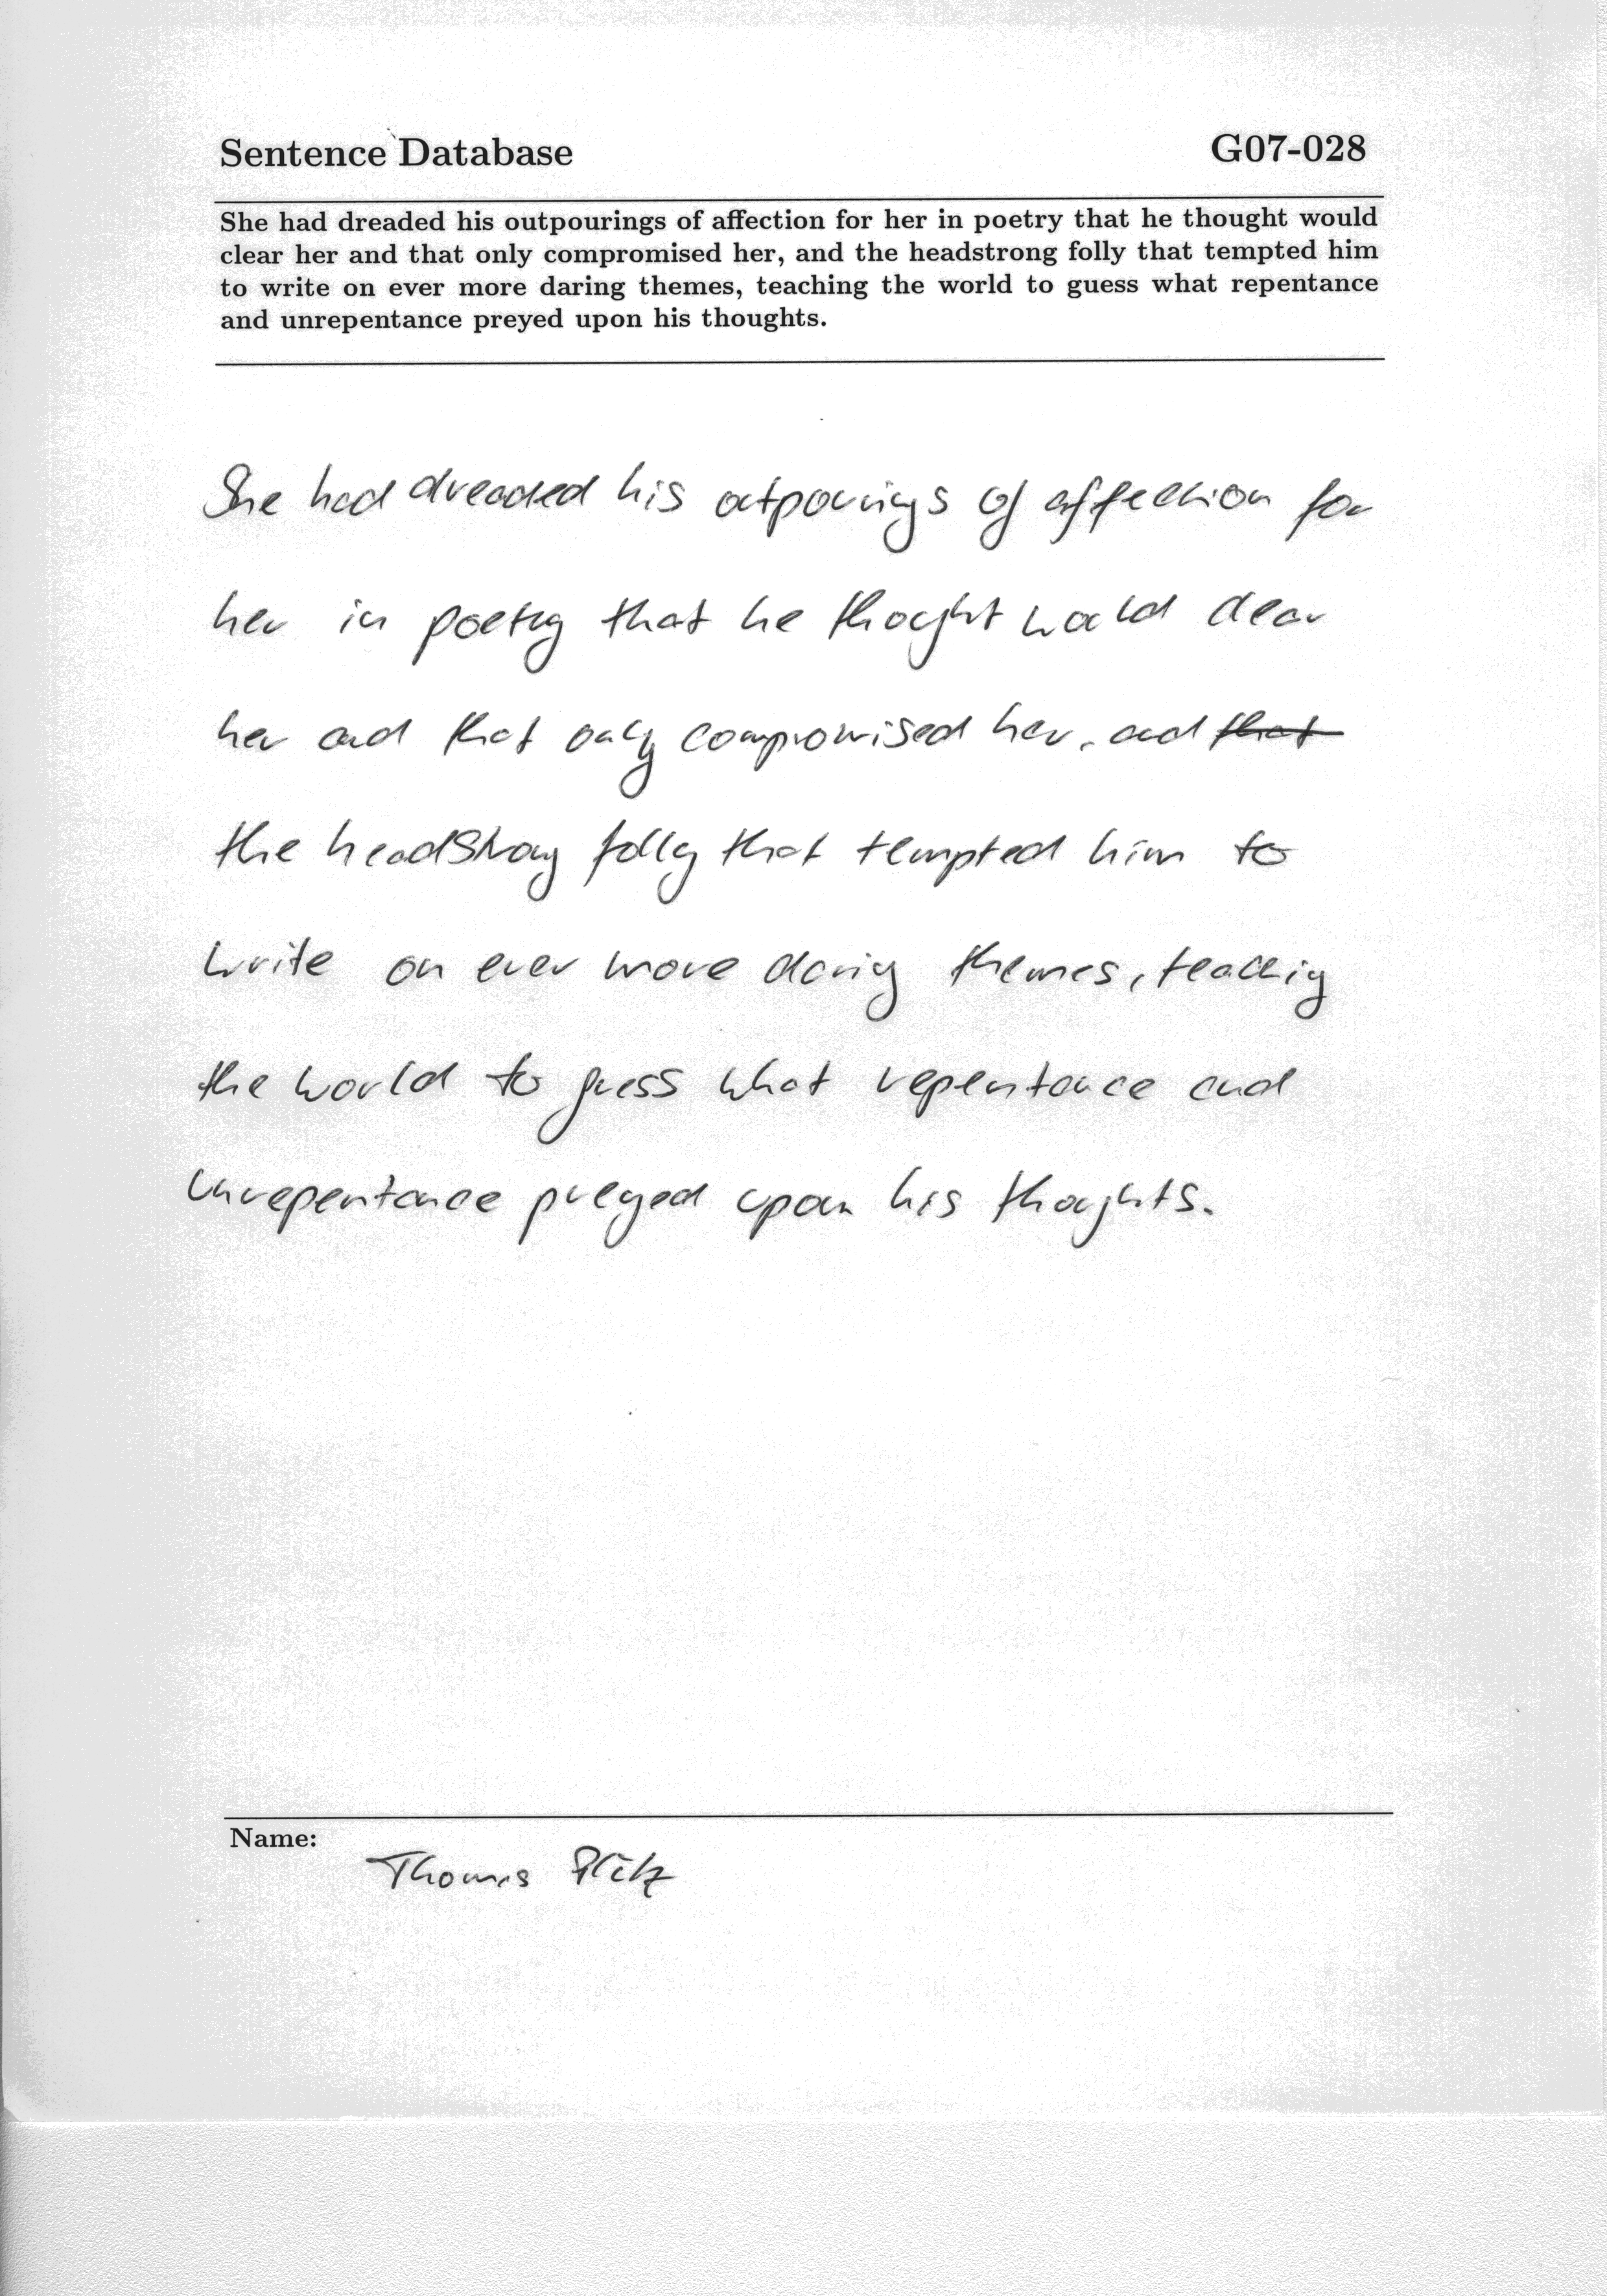

In [5]:
dataset[index][img_key]

In [6]:
# prompt = "<image>\nFree OCR. "
prompt = "<image>\nFree OCR. "
image_file = '../data/000/a01-000u.png'
output_path = '../test'
# infer(self, tokenizer, prompt='', image_file='', output_path = ' ', base_size = 1024, image_size = 640, crop_mode = True, test_compress = False, save_results = False):

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 640, image_size = 640, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 640, crop_mode = True

res = model.infer(
    tokenizer,
    prompt=prompt,
    image_file=image_file,
    output_path = output_path,
    base_size = 1024,
    image_size = 640,
    crop_mode=True,
    save_results = True,
    test_compress = False)

/home/diego/Documents/clases/procesamiento lenguaje natural/proyecto/venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
The attention mask is not set and cannot be inferred from input because pad tok

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([6, 100, 1280])
A A MOVE MOVE to to stop stop Mr. Mr. Gaitskell Gaitskell from from nominating nominating any any more more Labour Labour life life Peers Peers is is to to be be made made at at a a meeting meeting of of Labour Labour M M Ps Ps tomorrow. tomorrow. Mr. Mr. Michael Michael Foot Foot has has put put down down a a resolution resolution on on the the subject subject and and he he is is to to be be backed backed by by Mr. Mr. Will Will Griffiths, Griffiths, M M P P for for Manchester Manchester Exchange.

Exchange.

A A MOVE MOVE to to stop stop Mr. Mr. Gaitskell Gaitskell from from nominating nominating any any more more Labour Labour life life Peer Peer is is to to be be made made at at a a meeting meeting of of Labour Labour M M P's P's tomorrow. tomorrow. Mr. Mr. Michael Michael Foot Foot has has put put down down a a resolution resolution on on the the subject subject and and he he is is to to be be backe
backe
=====

image: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]



In [14]:
import pandas as pd
from datasets import Dataset, Image as HFImage
import os
import glob

# Load the texts
csv_path = '../texts.csv'
df = pd.read_csv(csv_path)

# Build a map from image id (e.g., 'a01-000u') to text
text_map = {row['image']: row['text'] for _, row in df.iterrows()}

# Find all image files across numbered subfolders under ../data
all_image_paths = glob.glob(os.path.join('..', 'data', '*', '*.png'))

records = []
missing_text = 0
for img_path in all_image_paths:
    image_id = os.path.splitext(os.path.basename(img_path))[0]
    text = text_map.get(image_id)
    if isinstance(text, str) and len(text.strip()) > 0:
        records.append({'image': img_path, 'text': text})
    else:
        missing_text += 1

if len(records) == 0:
    raise RuntimeError("No (image, text) pairs found. Check that texts.csv IDs match PNG basenames and that images exist under ../data/*/*.png")

# Create a Hugging Face Dataset with image paths and texts
dataset = Dataset.from_list(records)
# Cast image column to HF Image so it loads PIL images on access
dataset = dataset.cast_column('image', HFImage(decode=True))

print(f"Total images scanned: {len(all_image_paths)} | Matched pairs: {len(records)} | Missing texts: {missing_text}")
print(dataset)
first = dataset[0]
print(type(first['image']), first['image'].size)  # PIL image and its size
print(first['text'][:120])

Total images scanned: 1539 | Matched pairs: 609 | Missing texts: 930
Dataset({
    features: ['image', 'text'],
    num_rows: 609
})
<class 'PIL.PngImagePlugin.PngImageFile'> (2479, 3542)
Such a policy would unite the whole movement and lay the basis for the defeat of the present Tory Government , which has


In [ ]:
from transformers import TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model

# Pre-process the dataset: create a prompt, but KEEP image and text columns
# We'll keep 'image' so the Trainer can access it during compute_loss

def process_dataset(examples):
    prompts = [f"<image>\n{text}" for text in examples['text']]
    return {'prompt': prompts}

processed_dataset = dataset.map(process_dataset, batched=True)  # don't remove columns

# LoRA configuration
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
)

# Add LoRA to the model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Training arguments
training_args = TrainingArguments(
    output_dir="./deepseek-ocr-finetuned",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    logging_dir='./logs',
    logging_steps=10,
    save_steps=100,
    save_total_limit=1,
    fp16=True,
    remove_unused_columns=False,  # keep our custom columns
)

# Custom Trainer
class OCRTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        # Inputs come from processed_dataset and include: 'image' (PIL), 'text', and 'prompt'
        prompts = inputs.get("prompt")
        images = inputs.get("image")
        
        # NOTE: DeepSeek-OCR uses custom processing in infer(); for training, a proper processor may be required.
        # If the model forward requires token ids and pixel_values, you'd need to tokenize 'prompts' and
        # transform images accordingly. This is a minimal placeholder and might need adaptation.
        
        outputs = model(input_ids=prompts, pixel_values=images)
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

# Create Trainer
trainer = OCRTrainer(
    model=model,
    args=training_args,
    train_dataset=processed_dataset,
    tokenizer=tokenizer,
)

# Start training
trainer.train()

# Save the fine-tuned model
trainer.save_model("./deepseek-ocr-finetuned")

Map: 100%|██████████| 609/609 [00:00<00:00, 144844.41 examples/s]
/home/diego/Documents/clases/procesamiento lenguaje natural/proyecto/venv/lib/python3.12/site-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/diego/Documents/clases/procesamiento lenguaje natural/proyecto/venv/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
/tmp/ipykernel_11189/1083075203.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `OCRTrainer.__init__`. Use `processing_class` instead.
  trainer = OCRTrainer(

/home/diego/Documents/clases/procesamiento lenguaje natural/proyecto/venv/lib/python3.12/site-packages/

trainable params: 491,520 || all params: 3,336,597,760 || trainable%: 0.0147


ValueError: No columns in the dataset match the model's forward method signature. The following columns have been ignored: [prompt, image, text]. Please check the dataset and model. You may need to set `remove_unused_columns=False` in `TrainingArguments`.

In [ ]:
import pandas as pd
from datasets import Dataset, Image as HFImage
import os
import glob

# Load the texts
csv_path = '../texts.csv'
df = pd.read_csv(csv_path)

# Build a map from image id (e.g., 'a01-000u') to text
text_map = {row['image']: row['text'] for _, row in df.iterrows()}

# Find all image files across numbered subfolders under ../data
all_image_paths = glob.glob(os.path.join('..', 'data', '*', '*.png'))

records = []
missing_text = 0
for img_path in all_image_paths:
    image_id = os.path.splitext(os.path.basename(img_path))[0]
    text = text_map.get(image_id)
    if isinstance(text, str) and len(text.strip()) > 0:
        records.append({'image': img_path, 'text': text})
    else:
        missing_text += 1

if len(records) == 0:
    raise RuntimeError("No (image, text) pairs found. Check that texts.csv IDs match PNG basenames and that images exist under ../data/*/*.png")

# Create a Hugging Face Dataset with image paths and texts
dataset = Dataset.from_list(records)
# Cast image column to HF Image so it loads PIL images on access
dataset = dataset.cast_column('image', HFImage(decode=True))

print(f"Total images scanned: {len(all_image_paths)} | Matched pairs: {len(records)} | Missing texts: {missing_text}")
print(dataset)
first = dataset[0]
print(type(first['image']), first['image'].size)  # PIL image and its size
print(first['text'][:120])

Total images scanned: 1539 | Matched pairs: 609 | Missing texts: 930
Dataset({
    features: ['image', 'text'],
    num_rows: 609
})
<class 'PIL.PngImagePlugin.PngImageFile'> (2479, 3542)
Such a policy would unite the whole movement and lay the basis for the defeat of the present Tory Government , which has
